# Materials library

***

##### Tostada provides a built-in `materials.py` module to specify material properties for optical (Finite Difference Time Domain, 2D/3D) or mechanical (Lattice Particle Method, 2D) simulations. It also currently has a materials library for few materials regularly. Although, this needs to be updated regularly.

##### While the mechanical simulations use the in-house volume compensated lattice particle method code, for optical simulations, tostada relies on MIT's MEEP for wave simulations. It allows creation of a dispersive `meep.Medium` through a _**py-meep**_ package pre-installed during the setup. Combined with the `tostada.physics.meep_geometry` module, tostada then provides full suport to export any distributions to MEEP geometries.

In [ ]:
import meep as mp 
import numpy as np
import matplotlib.pyplot as plt
import tostada as tost

A custom material can be created by the `Material` class as:

In [5]:
tost_mat = tost.Material(name='New material',
                    refractive_index=2.5,
                    )

##### Note : Most of the properties are undefined during the class declaration as often times, it is unnecessary to know optical properties for a mechanical simulation or vice versa.

For mechanical simulations, a material defined this way can directly be imported in the `Lattice_Particle_Method_gpu` module. 

Here, we show how to access the optical properties. Take for instance, Anodized Aluminium Oxide ($Al_2O_3$). In `mechanical_testing_porous_media.ipynb` notebook, we used its pre-defined mechanical properties for mechanical simulations. Here, we shall look at its optical properties. 

In [6]:
from tostada.util.materials import AAO
AAO.optical_dispersions

array([[0.9    , 6.21064, 0.     ]])

The first, second and third elements here are $\sigma$, $\omega_0$ and $\gamma$ that parameterize a Lorentzian oscillator, respectively. In the case of a non-trivial dispersion, there are more than one oscillators describing the dispersion. It is necessary to describe the material dispersion in terms of Lorentzian, Drude oscillators because fourier-transforming dispersive refractive index data to time domain does not guarantee causlity or stable time-domain response. The oscillator, on the other hand, can be expressed as auxiliary differential equations (ADEs) that are simple, local-in-time ODEs that MEEP solves alongside Maxwell's equations. 

These parameters are directly usable in MEEP to create a `meep.Medium()` object. `Material.meep_dispersion()` does exactly this and is automatically called when `optical_dispersions != None`.

In [7]:
AAO.meep_medium # MEEP medium, use this in MEEP simulations.

Medium()

The frequency-domain dispersion of this material can be visualized by `Material.create_dispresion()` method that takes input wavelength array and returns a _[wvl, n, k ]_ array.

In [15]:
wvl = np.linspace(0.4,0.9,100)
nAAO = AAO.create_dispersion(wavelength=wvl)

The dispersion parameters used for each material has been obtained in a least-square optimization manner fitted to an experimentally obtained dataset. This is saved in `optical_measurements` class instance.

Text(0.5, 0, 'Wavelength ($\\mu$m)')

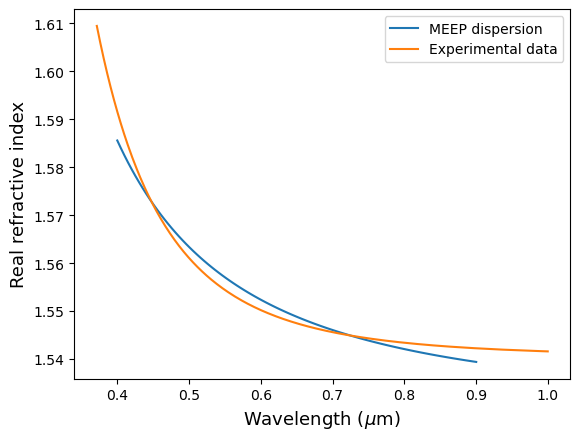

In [16]:
plt.plot(nAAO[:,0],nAAO[:,1],label='MEEP dispersion')
plt.plot(AAO.optical_measurements[:,0],AAO.optical_measurements[:,1],label='Experimental data')
plt.ylabel('Real refractive index',fontsize=13)
plt.legend()
plt.xlabel('Wavelength ($\mu$m)',fontsize=13)

Similarly, amorphous silicon can also be shown:

[[7.54066045 3.18200139 0.        ]
 [0.89870448 2.17986739 0.42239784]
 [1.66748523 2.49834208 0.35824486]]


Text(0.5, 0, 'Wavelength ($\\mu$m)')

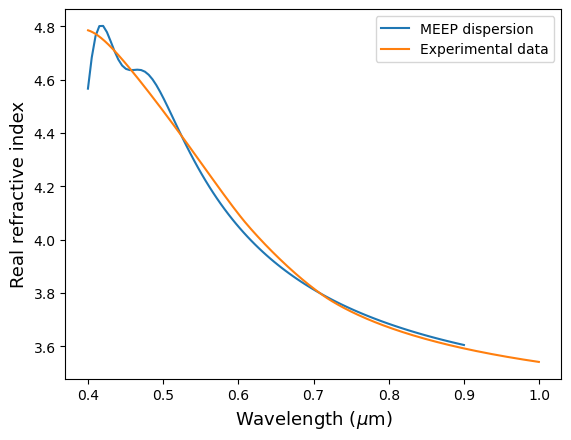

In [18]:
from tostada.util.materials import aSi
print (aSi.optical_dispersions)
n_aSi = aSi.create_dispersion(wavelength=wvl)
plt.plot(n_aSi[:,0],n_aSi[:,1],label='MEEP dispersion')
plt.plot(aSi.optical_measurements[:,0],aSi.optical_measurements[:,1],label='Experimental data')
plt.ylabel('Real refractive index',fontsize=13)
plt.legend()
plt.xlabel('Wavelength ($\mu$m)',fontsize=13)